## Foreign Gifts: UVA Analysis
#### *Name: Anna Phillips*

In [1]:
## Set up
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## **A. Initial UVA Data Exploration**

### 1. Load Data and fix date column to track gifts over time more easily

In [2]:
## 1. Load the data
df = pd.read_csv('ForeignGifts_edu.csv', low_memory = False)

# Asked ChatGPT what the date format meant and how to convert it
df["Foreign Gift Received Date"] = pd.to_datetime(
    df["Foreign Gift Received Date"],
    unit="D",
    origin="1899-12-30"
)
# What's the date range for this data frame?
display(df["Foreign Gift Received Date"].agg(["min", "max"]))

# create VA schools df for comparison purposes
va_schools = df[df["State"] == "VA"]


min   2014-01-01
max   2020-06-30
Name: Foreign Gift Received Date, dtype: datetime64[s]

***Important Takeaway***: *All of the gifts transactions in this data set occurred in the timeframe of 2014-2020. This seems to be a snapshot of available data, so we can't get a full picture of potential trends, but exploring repeated donors is still meaningful.*

In [3]:
# Merge duplicate country names into consistent format
country_map = {
    "KOREA": "SOUTH KOREA",
    "BOSNIA-HERCEGOVINA": "BOSNIA AND HERZEGOVINA"
}

df["Country of Giftor"] = (
    df["Country of Giftor"]
    .replace(country_map)
)

*During my analyses, I noticed some inconsistencies in `Country of Foreign Gift` names that messed up numbers, so I'm editing them in this document for my additional analyses.*

### 2. Do initial exploration of UVA gifts with summary statistics

In [4]:
# Snapshot of all UVA gifts
uva = df[df["Institution Name"] == "University of Virginia"]

display(uva.head())
print(f"{uva.shape[0]} total gifts")

,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
26235,26236,374500,University of Virginia,Charlottesville,VA,2014-07-02,3565,Monetary Gift,ENGLAND,West Yorkshire Police
26236,26237,374500,University of Virginia,Charlottesville,VA,2014-08-19,12265,Contract,ISRAEL,CureTech Ltd
26237,26238,374500,University of Virginia,Charlottesville,VA,2014-08-22,8187,Monetary Gift,ISRAEL,Branco Weiss Institute
26238,26239,374500,University of Virginia,Charlottesville,VA,2014-09-05,6437,Contract,ISRAEL,NovoCure Ltd
26239,26240,374500,University of Virginia,Charlottesville,VA,2014-09-22,216943,Contract,ISRAEL,InSightec-Image Guide Treatment Ltd


98 total gifts


In [87]:
# break down of contracts vs monetary gifts for UVA
print(f"Total money given to UVA: ${uva["Foreign Gift Amount"].sum():,.0f}")

display(uva.groupby("Gift Type")["Foreign Gift Amount"].describe())

uva["Foreign Gift Received Date"].agg(["min", "max"])

Total money given to UVA: $22,189,238


,count,mean,std,min,25%,50%,75%,max
Gift Type,,,,,,,,
Contract,64.0,231369.312500,370082.07040,31.0,9813.75,92130.5,259627.50,1708021.0
Monetary Gift,34.0,217105.941176,291247.23109,223.0,8290.50,67271.5,308750.75,1000000.0


min   2014-07-02
max   2019-12-19
Name: Foreign Gift Received Date, dtype: datetime64[s]

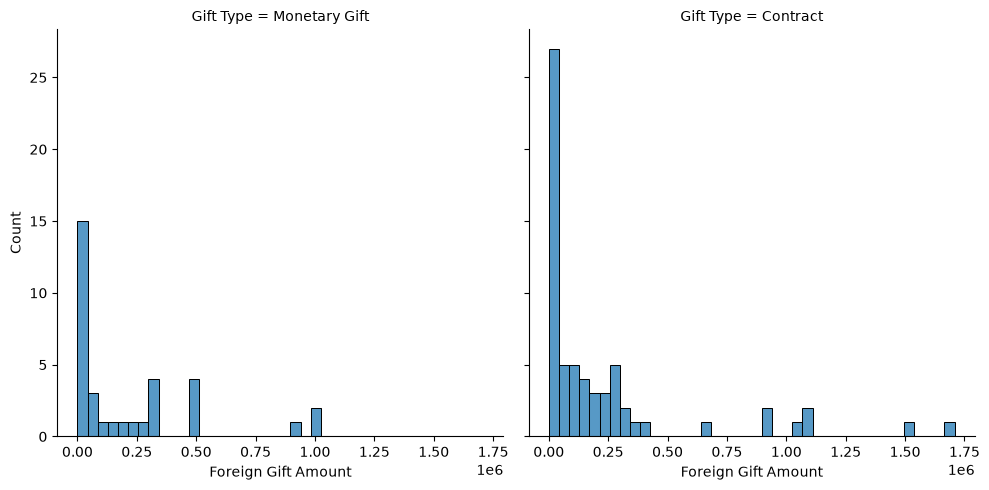

In [6]:
sns.displot(
    data=uva,
    x="Foreign Gift Amount",
    col="Gift Type",
    bins=40,
    facet_kws={"sharex": True, "sharey": True}
)
plt.show()

### 3. Investigate `Country` and `Giftor` columns
- How many countries give to UVA? How many individual giftors give to UVA? Are giftors associated with foreign governments or private companies?

In [7]:
# See how many giftors are associated with more than one country
giftor_country_counts = (
    df.groupby("Giftor Name")["Country of Giftor"]
    .nunique()
)

display(giftor_country_counts.sort_values(ascending=False).head(5).reset_index())

va_giftor_country_counts = (
    va_schools.groupby("Giftor Name")["Country of Giftor"]
    .nunique()
)
display(va_giftor_country_counts.sort_values(ascending=False).head().reset_index())

print(f"Full dataframe: {(giftor_country_counts > 1).sum()} donors associated with more than one country")
print(f"Virginia schools only: {(va_giftor_country_counts > 1).sum()} donors associated with more than one country")

,Giftor Name,Country of Giftor
0,Anonymous,43
1,Contracting Party,17
2,Individual,14
3,Corporation,13
4,Government,13


,Giftor Name,Country of Giftor
0,AO Foundation,1
1,Actelion,1
2,Adelphi Group Limited,1
3,"Allergan, Inc.",1
4,Anhui Zhifei Longcom Biopharmaceuti,1


Full dataframe: 195 donors associated with more than one country
Virginia schools only: 0 donors associated with more than one country


***Important Takeaway***: *When looking at the full list, some donors are associated with more than one country. Many of these instances are due to vague donor names like "University" or "Anonymous," but it still complicates extracting donor numbers at the country-level. For Virginia-level analysis, at least, there's no individual donor associated with multiple countries, which makes comparison between UVA and Virginia schools simpler.*

In [8]:
# How many unique countries and unique donors give to UVA?
print(f"Unique countries: {uva["Country of Giftor"].nunique()}")
print(f"Unique giftors: {uva["Giftor Name"].nunique()}")

Unique countries: 15
Unique giftors: 58


In [9]:
uva.groupby(["Country of Giftor", "Giftor Name"])["Foreign Gift Amount"].sum().sort_index(level="Country of Giftor").reset_index().groupby("Country of Giftor").head(2)

,Country of Giftor,Giftor Name,Foreign Gift Amount
0,BANGLADESH,International Centre for Diarrhoeal,919518
1,BANGLADESH,Intl Ctr for Diarrhoeal Disease,310001
5,BERMUDA,Hemera Foundation,900000
6,ENGLAND,Adelphi Group Limited,9750
7,ENGLAND,Charities Aid Foundation,727928
20,FINLAND,Danisco Sweeteners Oy,990331
21,FINLAND,FKD Therapies Oy,18053
22,FRANCE,Biom 'Up,5250
23,FRANCE,Genfit,19185
26,GUERNSEY,Harvest Group Holding,1000000


***Important Takeaway***: *Individual donor number (58) is not accurate due to different naming conventions for the same giftor (e.g., "Haydom Luther Hospital" vs. "Haydom Lutheran Hospital").*

In [10]:
# Highest UVA donor countries by gift count
display(uva.groupby("Country of Giftor")["Foreign Gift Amount"].describe().sort_values(by='count', ascending=False).head(10))

# Highest UVA donor countries by total gift sum
display(uva.groupby("Country of Giftor")["Foreign Gift Amount"].sum().sort_values(ascending=False).head(10).reset_index())

# Highest UVA giftor by gift count
display(uva.groupby(["Country of Giftor", "Giftor Name"])["Foreign Gift Amount"].describe().sort_values(by='count', ascending=False).head(10))

# Highest UVA giftor countries by total sum
display(uva.groupby(["Country of Giftor", "Giftor Name"])["Foreign Gift Amount"].sum().sort_values(ascending=False).head(10).reset_index())

,count,mean,std,min,25%,50%,75%,max
Country of Giftor,,,,,,,,
ENGLAND,31.0,62924.709677,86767.660725,223.0,8767.00,20982.0,68496.00,321029.0
ISRAEL,12.0,51971.250000,89549.598060,2650.0,6843.50,11010.5,31577.75,263250.0
BANGLADESH,10.0,422858.900000,409172.259567,31.0,69125.50,307225.5,794958.00,1077948.0
SWEDEN,10.0,400755.200000,640447.785631,5056.0,41651.25,133055.0,207028.75,1708021.0
FINLAND,7.0,144054.857143,154222.529150,1493.0,8280.00,84376.0,267967.50,370020.0
SOUTH KOREA,6.0,143797.833333,119685.494856,8333.0,59421.00,122467.0,220049.75,318537.0
FRANCE,5.0,50076.600000,57445.931691,5250.0,9350.00,9835.0,112470.00,113478.0
THE NETHERLANDS,4.0,181417.500000,43374.558199,146810.0,146810.00,171089.5,205697.00,236681.0
GUERNSEY,3.0,500000.000000,0.000000,500000.0,500000.00,500000.0,500000.00,500000.0


,Country of Giftor,Foreign Gift Amount
0,BANGLADESH,4228589
1,SWEDEN,4007552
2,TANZANIA,2776447
3,SWITZERLAND,2000000
4,ENGLAND,1950666
5,GUERNSEY,1500000
6,FINLAND,1008384
7,BERMUDA,900000
8,SOUTH KOREA,862787
9,SINGAPORE,805000


count           mean  \
Country of Giftor Giftor Name                                                
ENGLAND           Kirkhouse Trust                       9.0   40717.777778   
SWEDEN            AutoLiv Development AB                5.0  137043.400000   
FINLAND           Danisco Sweeteners Oy                 4.0  247582.750000   
ENGLAND           University of Newcastle               4.0   27415.750000   
FINLAND           FKD Therapies Oy                      3.0    6017.666667   
ENGLAND           Charities Aid Foundation              3.0  242642.666667   
                  GW Research Ltd                       3.0   18808.333333   
BANGLADESH        Intl. Cntr for Diarrihoeal Disease    3.0  232105.666667   
                  Intrnl Centre Diarrheal Disease       3.0  460965.333333   
ENGLAND           London School of Economics            3.0   20970.333333   

                                                                std       min  \
Country of Giftor Giftor Name                                                   
ENGLAND           Kirkhouse Trust                      42294.326427    3071.0   
SWEDEN            AutoLiv Development AB               85802.061387    5056.0   
FINLAND           Danisco Sweeteners Oy               119220.676354   84376.0   
ENGLAND           University of Newcastle              27463.192062     223.0   
FINLAND           FKD Therapies Oy                      3995.354344    1493.0   
ENGLAND           Charities Aid Foundation             50115.801593  211622.0   
                  GW Research Ltd                      14353.549886    7850.0   
BANGLADESH        Intl. Cntr for Diarrihoeal Disease  213875.469389      31.0   
                  Intrnl Centre Diarrheal Disease     555515.447851     498.0   
ENGLAND           London School of Economics           12031.504242    8933.0   

                                                           25%       50%  \
Country of Giftor Giftor Name                                              
ENGLAND           Kirkhouse Trust                       8601.0   15621.0   
SWEDEN            AutoLiv Development AB               99885.0  166225.0   
FINLAND           Danisco Sweeteners Oy               214909.0  267967.5   
ENGLAND           University of Newcastle              15751.0   21903.5   
FINLAND           FKD Therapies Oy                      4496.5    7500.0   
ENGLAND           Charities Aid Foundation            213734.0  215846.0   
                  GW Research Ltd                      10684.5   13519.0   
BANGLADESH        Intl. Cntr for Diarrihoeal Disease  137519.5  275008.0   
                  Intrnl Centre Diarrheal Disease     152474.0  304450.0   
ENGLAND           London School of Economics           14957.5   20982.0   

                                                            75%        max  
Country of Giftor Giftor Name                                               
ENGLAND           Kirkhouse Trust                      68082.00   128195.0  
SWEDEN            AutoLiv Development AB              207019.00   207032.0  
FINLAND           Danisco Sweeteners Oy               300641.25   370020.0  
ENGLAND           University of Newcastle              33568.25    65633.0  
FINLAND           FKD Therapies Oy                      8280.00     9060.0  
ENGLAND           Charities Aid Foundation            258153.00   300460.0  
                  GW Research Ltd                      24287.50    35056.0  
BANGLADESH        Intl. Cntr for Diarrihoeal Disease  348143.00   421278.0  
                  Intrnl Centre Diarrheal Disease     691199.00  1077948.0  
ENGLAND           London School of Economics           26989.00    32996.0

,Country of Giftor,Giftor Name,Foreign Gift Amount
0,SWEDEN,AstraZeneca,3208048
1,BANGLADESH,Intrnl Centre Diarrheal Disease,1382896
2,TANZANIA,Haydom Lutheran Hospital d/b/a Hayd,1100553
3,TANZANIA,Haydom Luther Hospital,1035339
4,GUERNSEY,Harvest Group Holding,1000000
5,SWITZERLAND,Lawrence D/ Karin S Howell,1000000
6,SWITZERLAND,Lawrence D & Karin S Howell,1000000
7,FINLAND,Danisco Sweeteners Oy,990331
8,BANGLADESH,Intnl Centre for Diarrhoeal Disease,919857
9,BANGLADESH,International Centre for Diarrhoeal,919518


***Important Takeaway***: *England has given us the most gifts by count (31), and Bangladesh has given us the most money overall ($4,228,589). Most UVA donors seem private, rather than governmental.*

### 4. Continue Country/Donor analysis by exploring date column
- Does UVA have consistent donors over time?

In [ ]:
# Date range of UVA gifts
display(
    uva["Foreign Gift Received Date"].agg(["min", "max"])
)

# UVA gifts per year
display(
    uva["Foreign Gift Received Date"]
    .dt.year
    .value_counts()
    .sort_index()
)

min   2014-07-02
max   2019-12-19
Name: Foreign Gift Received Date, dtype: datetime64[s]

Foreign Gift Received Date
2014    15
2015    10
2016    31
2017    25
2018     9
2019     8
Name: count, dtype: int64

In [ ]:
# ChatGPT helped write this code, because I'm still getting used to transitioning
# from R to pandas (I'm still getting familiar with how to use .agg() vs R's mutate function)

# Summary of how many years a country has given to UVA (how many gifts/total sum)
country_year_summary = (
    uva.groupby("Country of Giftor")
    .agg(
        years=("Foreign Gift Received Date",
               lambda x: sorted(x.dt.year.unique())),
        n_years=("Foreign Gift Received Date",
                 lambda x: x.dt.year.nunique()),
        gift_count=("Gift Type", "count"),
        gift_sum=("Foreign Gift Amount", "sum")
    )
    .sort_values("gift_sum", ascending=False)
)

display(country_year_summary)

,years,n_years,gift_count,gift_sum
Country of Giftor,,,,
BANGLADESH,"[2014, 2015, 2016, 2017, 2019]",5,10,4228589
SWEDEN,"[2015, 2016, 2018, 2019]",4,10,4007552
TANZANIA,"[2017, 2018]",2,3,2776447
SWITZERLAND,[2019],1,2,2000000
ENGLAND,"[2014, 2015, 2016, 2017]",4,31,1950666
GUERNSEY,"[2017, 2018, 2019]",3,3,1500000
FINLAND,"[2016, 2017, 2018]",3,7,1008384
BERMUDA,[2016],1,1,900000
SOUTH KOREA,"[2015, 2016]",2,6,862787


***Important Takeaway***: *Focus on countries/giftors with repeated donations when looking at potential new foreign donors for UVA. In our current donor list, Bangladesh, Sweden, and England have given most consistently over the years.*

### **Initial UVA Exploration Summary**
- 98 observations of gifts ($22,189,238 total)
    - 64 contracts ($231,369 average) vs 34 monetary gifts ($217,105 average)
- Gifts were spread over 2014-2019
    - England, Bangladesh, and Sweden have been UVA's most consistent donors
- 15 unique countries overall
    - Analysis initially showed *58 unique giftors*, but further investigation revealed this number to be inflated due to inconsistent naming conventions
    - UVA's top giftors aren't officially associated with their country's government - most are private institutions

### **A. UVA vs. Other Virginia Schools Exploration**


### 1. Generate summary statistics for other Virginia schools
- The list only contains VA public schools, so I chose these as my peer institutions rather than expanding into other states

In [ ]:
# Examine other VA schools
print(va_schools.shape)

display(va_schools.head())

# ChatGPT helped write this code, because I'm still getting used to transitioning
# from R to pandas (I'm still getting familiar with how to use .agg() vs R's mutate function)

# overview of gifts for all VA schools
va_school_summary = (
    va_schools
    .groupby("Institution Name")
    .agg(
        Gift_Count=("Gift Type", "count"),
        Total_Amount=("Foreign Gift Amount", "sum"),
        Total_Countries=("Country of Giftor", "nunique")
    )
    .sort_values("Total_Amount", ascending=False)
    .reset_index()
)

display(va_school_summary)

(292, 10)


,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
26103,26104,370500,College of William & Mary,Williamsburg,VA,2016-03-23,19613,Monetary Gift,CHINA,Hanban
26104,26105,370500,College of William & Mary,Williamsburg,VA,2016-03-23,18695,Monetary Gift,CHINA,Hanban
26105,26106,370500,College of William & Mary,Williamsburg,VA,2016-06-21,556,Monetary Gift,CHINA,Hanban
26106,26107,370500,College of William & Mary,Williamsburg,VA,2016-09-30,10380,Monetary Gift,CHINA,Hanban
26107,26108,370500,College of William & Mary,Williamsburg,VA,2016-12-07,51600,Monetary Gift,CHINA,Hanban


,Institution Name,Gift_Count,Total_Amount,Total_Countries
0,Virginia Commonwealth University,115,89163583,23
1,George Mason University,38,65435604,10
2,University of Virginia,98,22189238,15
3,Virginia Polytechnic Institute & State University,24,11792062,14
4,College of William & Mary,17,3384498,3


*UVA has received substantially less money overall than VCU and GMU.*

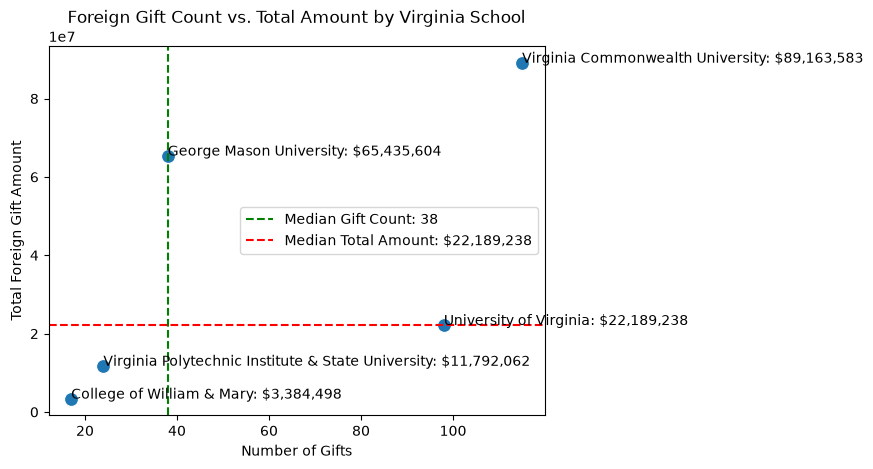

In [ ]:
# values for plot
gift_count_median = va_school_summary["Gift_Count"].median()
gift_sum_median = va_school_summary["Total_Amount"].median()


# ChatGPT helped write this code, because I'm still getting used to transitioning
# from R to python visuals (I know how to do these things in R, but I'm still getting used
# to seaborn/plotly syntax and formatting)
## Additionally, I did not ask ChatGPT with help on what visualization to choose -- I already
## knew that a scatterplot with quadrants was how I wanted to do it -- I just needed help
## with how seaborn is used to do that

sns.scatterplot(
    data=va_school_summary,
    x="Gift_Count",
    y="Total_Amount",
    s=100
)

# quadrant lines
plt.axvline(
    gift_count_median,
    linestyle="--",
    c="green",
    label=f"Median Gift Count: {gift_count_median:.0f}"
)

plt.axhline(
    gift_sum_median,
    linestyle="--",
    c="red",
    label=f"Median Total Amount: ${gift_sum_median:,.0f}"
)

# school labels
for _, row in va_school_summary.iterrows():
    plt.text(
        row["Gift_Count"],
        row["Total_Amount"],
        f"{row['Institution Name']}: ${row['Total_Amount']:,.0f}"
    )

plt.xlabel("Number of Gifts")
plt.ylabel("Total Foreign Gift Amount")
plt.title("Foreign Gift Count vs. Total Amount by Virginia School")
plt.legend()

plt.show()

***Takeaways***: *There's a big discrepancy between schools in terms of total gift amount and gift count. UVA receives the second highest count of gifts, but falls way behind GMU and VCU in terms of total gift sum.* 

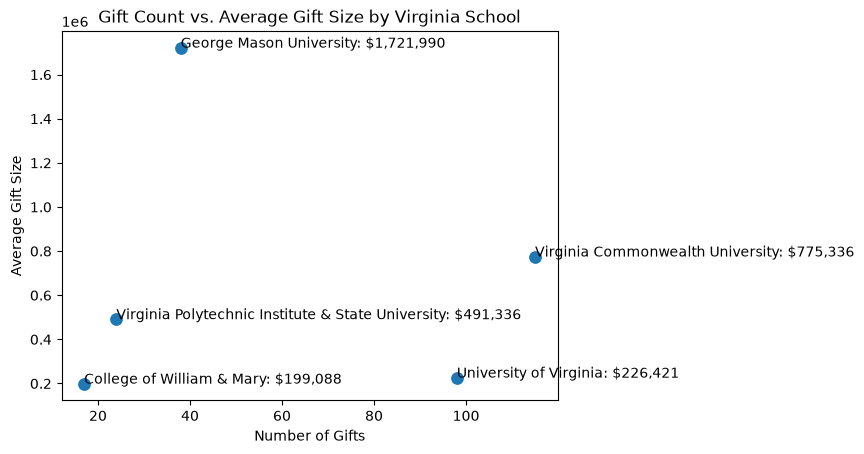

In [ ]:
# ChatGPT helped write this code, because I'm still getting used to transitioning
# from R to python visuals (I know how to do these things in R, but I'm still getting used
# to seaborn/plotly syntax and formatting)
## Additionally, I did not ask ChatGPT with help on what visualization to choose, I just 
## needed help with how seaborn is used

va_school_summary["Avg_Gift"] = (
    va_school_summary["Total_Amount"] /
    va_school_summary["Gift_Count"]
)

sns.scatterplot(
    data=va_school_summary,
    x="Gift_Count",
    y="Avg_Gift",
    s=100
)

for _, row in va_school_summary.iterrows():
    plt.text(
        row["Gift_Count"],
        row["Avg_Gift"],
        f"{row['Institution Name']}: ${row['Avg_Gift']:,.0f}"
    )

plt.xlabel("Number of Gifts")
plt.ylabel("Average Gift Size")
plt.title("Gift Count vs. Average Gift Size by Virginia School")

plt.show()

***Takeaways***: *We can also see clear differences in average gift size between schools. Even though UVA receives a higher count of gifts, the average size of those gifts is much smaller than other schools. VCU, for example, receives more gifts AND those gifts have an average size that's more than 3x bigger than UVA's.*

In [16]:
# How many unique countries donate to each VA school
va_schools.groupby("Institution Name")["Country of Giftor"].nunique().sort_values(ascending=False).reset_index()

,Institution Name,Country of Giftor
0,Virginia Commonwealth University,23
1,University of Virginia,15
2,Virginia Polytechnic Institute & State University,14
3,George Mason University,10
4,College of William & Mary,3


### 2. Dive into differences between countries who give to VA schools
- How does VCU and GMU have so much money? How does VCU harness both high gift counts and high avg gift amount?

In [17]:
# VA schools by highest total donor
display(va_schools.groupby(['Institution Name', 'Country of Giftor'])["Foreign Gift Amount"].sum().reset_index().sort_values(["Institution Name", "Foreign Gift Amount"],ascending=[True, False]).groupby("Institution Name").head(1))

# VA schools by highest single donation

va_schools.groupby(['Institution Name', 'Country of Giftor'])['Foreign Gift Amount'].max().sort_values(ascending=False).groupby(level=0).head(1).reset_index()

,Institution Name,Country of Giftor,Foreign Gift Amount
2,College of William & Mary,SAUDI ARABIA,2262530
10,George Mason University,SAUDI ARABIA,54183796
13,University of Virginia,BANGLADESH,4228589
42,Virginia Commonwealth University,QATAR,78867097
53,Virginia Polytechnic Institute & State University,ENGLAND,2586931


,Institution Name,Country of Giftor,Foreign Gift Amount
0,Virginia Commonwealth University,QATAR,40092588
1,George Mason University,SAUDI ARABIA,5668346
2,Virginia Polytechnic Institute & State University,ENGLAND,1750000
3,University of Virginia,SWEDEN,1708021
4,College of William & Mary,SAUDI ARABIA,932265


*By looking at the countries who have given the most AND the countries who have given the highest single donation, we can see that other Virginia schools have made connections with Middle Eastern countries like Saudi Arabia and Qatar.*

In [ ]:
# ChatGPT helped write this code, because I'm still getting used to transitioning
# from R to pandas -- I know how to do merges/joins in R but I'm not familiar enough
# with pandas yet to do it manually


# comparing countries/donors across all VA schools
uva_donors = (
    uva[["Country of Giftor", "Giftor Name"]]
    .drop_duplicates()
)

other_va = (
    va_schools[
        va_schools["Institution Name"] != "University of Virginia"
    ]
)

non_uva_donors = (
    other_va
    .merge(
        uva_donors,
        on=["Country of Giftor", "Giftor Name"],
        how="left",
        indicator=True
    )
    .query('_merge == "left_only"')
    .drop(columns="_merge")
)

non_uva_donor_summary = (
    non_uva_donors
    .groupby([
        "Institution Name",
        "Country of Giftor",
        "Giftor Name"
    ])
    .agg(
        gift_count=("Foreign Gift Amount", "count"),
        total_sum=("Foreign Gift Amount", "sum")
    )
    .reset_index()
    .sort_values(["gift_count", "total_sum"],ascending=[False, False])
    .head(15)
)

display(non_uva_donor_summary)

,Institution Name,Country of Giftor,Giftor Name,gift_count,total_sum
13,George Mason University,SAUDI ARABIA,Royal Embassy of Saudi Arabia,12,54183796
2,College of William & Mary,CHINA,Hanban,10,309453
18,George Mason University,UNITED ARAB EMIRATES,Embassy of the United Arab Emirates,6,4406188
66,Virginia Commonwealth University,QATAR,Qatar National Research Fund,6,573533
49,Virginia Commonwealth University,GERMANY,Boehringer Ingelheim Pharmaceutical,5,1489324
34,Virginia Commonwealth University,ENGLAND,"Allergan, Inc.",5,285692
4,College of William & Mary,SAUDI ARABIA,Royal Embassy of Saudi Arabia/SACM,4,2262530
9,George Mason University,KUWAIT,Embassy of the State of Kuwait,4,1388173
55,Virginia Commonwealth University,ISRAEL,"Teva Pharmaceuticals Industries, Lt",4,146655
29,Virginia Commonwealth University,CANADA,University Health Network,4,137569


In [ ]:
# I copied the alluvial plot code from the Lab1 notebook and changed the dataframe used

import pandas as pd
import plotly.graph_objects as go


giftor = 'Country of Giftor'
recipi = 'Institution Name'
flow = 'Foreign Gift Amount'
N = 25

flows = (
    uva.groupby([giftor, 
                recipi])
      [flow]
      .sum()
      .nlargest(N)
      .reset_index()
)

labels = (
    flows[giftor].tolist()
    + flows[recipi].tolist()
)

labels = list(dict.fromkeys(labels))

fig = go.Figure(
    go.Sankey(
        node=dict(label=labels),
        link=dict(
            source=flows[giftor]
                        .map(labels.index),
            target=flows[recipi]
                        .map(labels.index),
            value=flows[flow]
        )
    )
)

fig.show()

***Important Takeaway***: *UVA's donor distribution is made up of more countries with similar donation amounts, compared to VCU and GMU (shown below), who get the majority of their money from one donor (Qatar and Saudia Arabia respectively).*

In [ ]:
# I copied the alluvial plot code from the Lab1 notebook and changed the dataframe used

import pandas as pd
import plotly.graph_objects as go


giftor = 'Country of Giftor'
recipi = 'Institution Name'
flow = 'Foreign Gift Amount'
N = 25

flows = (
    va_schools.groupby([giftor, 
                recipi])
      [flow]
      .sum()
      .nlargest(N)
      .reset_index()
)

labels = (
    flows[giftor].tolist()
    + flows[recipi].tolist()
)

labels = list(dict.fromkeys(labels))

fig = go.Figure(
    go.Sankey(
        node=dict(label=labels),
        link=dict(
            source=flows[giftor]
                        .map(labels.index),
            target=flows[recipi]
                        .map(labels.index),
            value=flows[flow]
        )
    )
)

fig.show()

***Important Takeaway***: *VCU and GMU have received the majority of their money from a single country, whereas UVA has maintained a higher number of consistent (albeit smaller) donations.*

In [ ]:
# I copied the alluvial plot code from the Lab1 notebook and changed the dataframe used

import pandas as pd
import plotly.graph_objects as go

no_qatar_saudi = va_schools[(va_schools["Country of Giftor"] != "SAUDI ARABIA") & (va_schools["Country of Giftor"] != "QATAR")]

giftor = 'Country of Giftor'
recipi = 'Institution Name'
flow = 'Foreign Gift Amount'
N = 25

flows = (
    no_qatar_saudi.groupby([giftor, 
                recipi])
      [flow]
      .sum()
      .nlargest(N)
      .reset_index()
)

labels = (
    flows[giftor].tolist()
    + flows[recipi].tolist()
)

labels = list(dict.fromkeys(labels))

fig = go.Figure(
    go.Sankey(
        node=dict(label=labels),
        link=dict(
            source=flows[giftor]
                        .map(labels.index),
            target=flows[recipi]
                        .map(labels.index),
            value=flows[flow]
        )
    )
)

fig.show()

*Without Qatar and Saudi Arabia in the picture, UVA has the most gifts out of Virginia schools.*

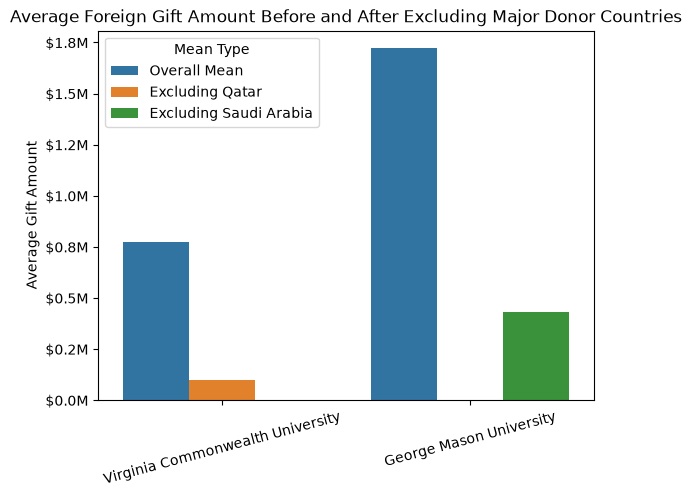

In [ ]:
# ChatGPT helped write this code, because I'm still getting used to transitioning
# from R to python visuals (I know how to do these things in R, but I'm still getting used
# to seaborn/plotly syntax and formatting)
## Additionally, I did not ask ChatGPT with help on what visualization to choose, I just 
## needed help with how seaborn is used (especially formatting axes and money amounts)

vcu_mean = df[df["Institution Name"] == "Virginia Commonwealth University"][
    "Foreign Gift Amount"
].mean()
vcu_adj_mean = df[
    (df["Institution Name"] == "Virginia Commonwealth University")
    & (df["Country of Giftor"] != "QATAR")
]["Foreign Gift Amount"].mean()

gmu_mean = df[df["Institution Name"] == "George Mason University"][
    "Foreign Gift Amount"
].mean()
gmu_adj_mean = df[
    (df["Institution Name"] == "George Mason University")
    & (df["Country of Giftor"] != "SAUDI ARABIA")
]["Foreign Gift Amount"].mean()

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

comparison = pd.DataFrame({
    "School": [
        "Virginia Commonwealth University",
        "Virginia Commonwealth University",
        "George Mason University",
        "George Mason University"
    ],
    "Mean Type": [
        "Overall Mean",
        "Excluding Qatar",
        "Overall Mean",
        "Excluding Saudi Arabia"
    ],
    "Mean Gift Amount": [
        vcu_mean,
        vcu_adj_mean,
        gmu_mean,
        gmu_adj_mean
    ]
})

sns.barplot(
    data=comparison,
    x="School",
    y="Mean Gift Amount",
    hue="Mean Type"
)

plt.ylabel("Average Gift Amount")
plt.xlabel("")
plt.title("Average Foreign Gift Amount Before and After Excluding Major Donor Countries")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda y, pos: f"${y/1e6:.1f}M")
)

plt.xticks(rotation=15)
plt.show()

### 3. Look at the donor-level for VA schools
- Even if some schools get the majority of their money from one country, how is that money split across multiple donors?

In [21]:
va_schools[(va_schools["Country of Giftor"] == "QATAR") | (va_schools["Country of Giftor"] == "SAUDI ARABIA")].head()

,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
26108,26109,370500,College of William & Mary,Williamsburg,VA,2016-12-31,416266,Monetary Gift,SAUDI ARABIA,Royal Embassy of Saudi Arabia/SACM
26111,26112,370500,College of William & Mary,Williamsburg,VA,2017-12-31,932265,Monetary Gift,SAUDI ARABIA,Royal Embassy of Saudi Arabia/SACM
26116,26117,370500,College of William & Mary,Williamsburg,VA,2018-12-31,303978,Monetary Gift,SAUDI ARABIA,Royal Embassy of Saudi Arabia/SACM
26118,26119,370500,College of William & Mary,Williamsburg,VA,2019-12-31,610021,Monetary Gift,SAUDI ARABIA,Royal Embassy of Saudi Arabia/SACM
26125,26126,373500,Virginia Commonwealth University,Richmond,VA,2015-03-05,272980,Contract,QATAR,Qatar National Research Fund


In [ ]:
# ChatGPT helped write this code, because I'm still getting used to transitioning
# from R to python/pandas, especially using the .agg() function with lambda functions

qatar_saudi_by_school = (
    va_schools[
        va_schools["Country of Giftor"].isin(["QATAR", "SAUDI ARABIA"])
    ]
    .groupby(["Institution Name", "Country of Giftor"])
    .agg(
        gift_count=("Foreign Gift Amount", "count"),
        total_received=("Foreign Gift Amount", "sum"),
        years=(
            "Foreign Gift Received Date",
            lambda x: sorted(x.dt.year.unique())
        )
    )
    .reset_index()
    .sort_values(
        ["Institution Name", "total_received"],
        ascending=[True, False]
    )
)

display(qatar_saudi_by_school)

,Institution Name,Country of Giftor,gift_count,total_received,years
0,College of William & Mary,SAUDI ARABIA,4,2262530,"[2016, 2017, 2018, 2019]"
2,George Mason University,SAUDI ARABIA,12,54183796,"[2014, 2015, 2016, 2017, 2018, 2019]"
1,George Mason University,QATAR,2,813266,"[2018, 2019]"
3,Virginia Commonwealth University,QATAR,10,78867097,"[2015, 2019]"
4,Virginia Commonwealth University,SAUDI ARABIA,1,12470,[2019]


***Important Takeaway***: *Looking only at the country level is deceiving -- what specific donors are giving from these countries? Is there any individual donor overlap between VA schools?*

In [23]:
va_schools[(va_schools["Country of Giftor"] == "QATAR") | (va_schools["Country of Giftor"] == "SAUDI ARABIA")].groupby(["Giftor Name", "Institution Name"])["Foreign Gift Amount"].sum().sort_values(ascending=False)

Giftor Name                         Institution Name                
Qatar Foundation                    Virginia Commonwealth University    78285875
Royal Embassy of Saudi Arabia       George Mason University             54183796
Royal Embassy of Saudi Arabia/SACM  College of William & Mary            2262530
Emg of the State of Qatar Cultural  George Mason University               813266
Qatar National Research Fund        Virginia Commonwealth University      573533
King Abdulaziz University           Virginia Commonwealth University       12470
Qatar University                    Virginia Commonwealth University        7689
Name: Foreign Gift Amount, dtype: int64

*The only common donor between schools for Qatar and Saudi Arabia are the Royal Embassy of Saudi Arabia (has given money to both GMU and W&M).*

In [ ]:
# VA schools who share the same individual donor


# ChatGPT helped write this code, because I'm still getting used to transitioning
# from R to python/pandas (I'm not familiar with the .query() parameter)

va_shared_giftors = (
    va_schools
    .groupby(["Country of Giftor", "Giftor Name"])
    .agg(
        n_schools=("Institution Name", "nunique"),
        schools=("Institution Name", lambda x: sorted(x.unique())),
        gift_count=("Foreign Gift Amount", "count"),
        total_amount=("Foreign Gift Amount", "sum")
    )
    .reset_index()
    .query("n_schools > 1")
    .sort_values(
        ["n_schools", "total_amount"],
        ascending=[False, False]
    )
)

display(va_shared_giftors)

,Country of Giftor,Giftor Name,n_schools,schools,gift_count,total_amount


***Important Takeaway***: *At first glance, there are no common individual donors between VA schools, but we've already seen that the Royal Embassy of Saudi Arabia was listed under two different naming conventions. So we need to standardize names across donors and retry.*

In [25]:
# Preserve original column values
df["Giftor Name Original"] = df["Giftor Name"]

In [ ]:
# Full giftor mapping edits are implemented here but the rationale for countries 
# chosen occurs further down

# ChatGPT helped write this code because manually going through donors for each country
# was not a productive use of my time, so I gave lists of the top 5 countries to ChatGPT to
# notice patterns and then write the mapping code for me

from giftor_mapping import giftor_map

df["Giftor Name"] = (
    df["Giftor Name"]
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

df["Giftor Name"] = df["Giftor Name"].replace(giftor_map)

# also add edits to va_schools
va_schools["Giftor Name"] = (
    df["Giftor Name"]
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

va_schools["Giftor Name"] = va_schools["Giftor Name"].replace(giftor_map)

display(
    df.groupby("Country of Giftor")["Giftor Name"].unique().reset_index().head()
)

,Country of Giftor,Giftor Name
0,AFGHANISTAN,"[Council for the Develop of Social, Ministry o..."
1,AMERICAN SAMOA,"[American Samoa, Dept of Education, American S..."
2,ANGOLA,"[West Africa Mgmt Services, Western African Ma..."
3,ANTIGUA,[American University of Antigua]
4,ARGENTINA,"[nan, CAF, UNITECBLUE, UNITECBIO S.A., AEROPUE..."


In [ ]:
# ChatGPT helped me write this code because I'm still getting used to how .agg() is used
# in pandas vs. mutate() in R

# VA schools who receive donations from the same country
va_giftors = (
    va_schools[va_schools["Institution Name"] != "University of Virginia"]
    .groupby("Country of Giftor")
    .agg(
        n_schools=("Institution Name", "nunique"),
        schools=("Institution Name", lambda x: sorted(x.unique())),
        gift_count=("Foreign Gift Amount", "count"),
        total_amount=("Foreign Gift Amount", "sum")
    )
    .reset_index()
    .query("n_schools > 1")
    .sort_values(
        ["n_schools", "total_amount"],
        ascending=[False, False]
    )
)

display(va_giftors.head())

,Country of Giftor,n_schools,schools,gift_count,total_amount
22,SAUDI ARABIA,3,"[College of William & Mary, George Mason University, Virginia Commonwealth University]",17,56458796
29,UNITED ARAB EMIRATES,3,"[George Mason University, Virginia Commonwealth University, Virginia Polytechnic Institute & State University]",13,7104720
4,CHINA,3,"[College of William & Mary, Virginia Commonwealth University, Virginia Polytechnic Institute & State University]",18,2028384
3,CANADA,3,"[College of William & Mary, Virginia Commonwealth University, Virginia Polytechnic Institute & State University]",18,1216557
21,QATAR,2,"[George Mason University, Virginia Commonwealth University]",12,79680363


In [ ]:
# ChatGPT helped me write this code because I'm still getting used to how .agg() is used
# in pandas vs. mutate() in R

# VA schools who share the same individual donor
va_shared_giftors = (
    va_schools
    .groupby(["Country of Giftor", "Giftor Name"])
    .agg(
        n_schools=("Institution Name", "nunique"),
        schools=("Institution Name", lambda x: sorted(x.unique())),
        gift_count=("Foreign Gift Amount", "count"),
        total_amount=("Foreign Gift Amount", "sum")
    )
    .reset_index()
    .query("n_schools > 1")
    .sort_values(
        ["n_schools", "total_amount"],
        ascending=[False, False]
    )
)

display(va_shared_giftors)

,Country of Giftor,Giftor Name,n_schools,schools,gift_count,total_amount


*Even after a preliminary cleaning of the `Giftor Name` column, there are still no shared individual donors between schools. However, based on my own research, GMU's money did come from a partnership with SACM, so I'll discuss that more in my report document.*

## **B. Market-level Analysis**


### 1. Explore countries who give gifts to the most schools possible
- Who is the most free with their funds? Do they consistently give to many schools over multiple years or is it just multiple one-time donations?

In [43]:
# countries who give to most number of unique schools
country_school_counts = (
    df.groupby("Country of Giftor")["Institution Name"]
    .nunique()
    .sort_values(ascending=False)
)

display(country_school_counts.head())

Country of Giftor
CHINA           154
SAUDI ARABIA    152
CANADA          122
ENGLAND         121
JAPAN           101
Name: Institution Name, dtype: int64

In [ ]:
# Find countries who give to large numbers of unique schools consistently

# ChatGPT helped me write this code because I'm not familiar enough with how to navigate
# datetime data in pandas/python

country_school_year_counts = (
    df.assign(
        Year=df["Foreign Gift Received Date"].dt.year
    )
    .groupby(["Country of Giftor", "Institution Name"])["Year"]
    .nunique()
    .reset_index(name="n_years")
)

repeat_school_giving = country_school_year_counts[
    country_school_year_counts["n_years"] > 1
]

country_repeat_schools = (
    repeat_school_giving
    .groupby("Country of Giftor")["Institution Name"]
    .nunique()
    .sort_values(ascending=False)
)

display(country_repeat_schools.head(5))

Country of Giftor
CHINA           100
ENGLAND          80
SAUDI ARABIA     79
JAPAN            72
CANADA           71
Name: Institution Name, dtype: int64

*5 countries have given to over 100 unique schools, showing a willingness to cast a wide net vs always sticking with the same recipients. Additionally, when you filter the data set further to countries who give to the largest number of unique schools more than once, these 5 still remain at the time. However, looking at the giftor-level will provide the most meaningful information. **Nonetheless, I used these top five countries to choose which country's giftor columns to prioritize cleaning.***

In [ ]:
# top giftors (with their country name) who gave to the biggest number of unique schools
country_school_counts = (
    df.groupby(["Country of Giftor", "Giftor Name"])["Institution Name"]
    .nunique()
    .sort_values(ascending=False)
    .reset_index()
)

country_school_counts.head(13)

,Country of Giftor,Giftor Name,Institution Name
0,SAUDI ARABIA,Saudi Arabian Cultural Mission,79
1,SAUDI ARABIA,King Abdullah University of Science and Technology,21
2,CHINA,Hanban / Confucius Institute,16
3,ENGLAND,Wellcome Trust,16
4,ENGLAND,GlaxoSmithKline,16
5,KUWAIT,Embassy of Kuwait,16
6,SAUDI ARABIA,Royal Embassy of Saudi Arabia,15
7,CHINA,"Huawei Technologies Co., Ltd.",15
8,DENMARK,Novo Nordisk,12
9,ENGLAND,AstraZeneca PLC,11


In [ ]:
# ChatGPT helped me write this code because I'm not familiar enough with how to navigate
# merging and the .agg() function yet for pandas 

# Donors that appear in Virginia schools
va_giftors = (
    va_schools["Giftor Name"]
    .dropna()
    .unique()
)

# Rest of dataset, excluding Virginia schools
non_va = df[~df.index.isin(va_schools.index)]

# Keep only donors that also appear in Virginia
shared_giftors = non_va[
    non_va["Giftor Name"].isin(va_giftors)
]

va_donor_summary = (
    va_schools
    .dropna(subset=["Giftor Name"])
    .groupby("Giftor Name")
    .agg(
        va_schools=("Institution Name", lambda x: sorted(x.unique())),
        n_va_schools=("Institution Name", "nunique")
    )
    .reset_index()
)

non_va_donor_summary = (
    non_va
    .dropna(subset=["Giftor Name"])
    .groupby("Giftor Name")
    .agg(
        other_schools=("Institution Name", lambda x: sorted(x.unique())),
        n_other_schools=("Institution Name", "nunique")
    )
    .reset_index()
)


# merge summaries to create va vs non va giftor dataframe
shared_giftor_summary = (
    va_donor_summary
    .merge(
        non_va_donor_summary,
        on="Giftor Name",
        how="inner"
    )
    .sort_values(
        ["n_other_schools", "n_va_schools"],
        ascending=False
    )
)

# Country info to merge with summary because some giftor names aren't obvious
giftor_countries = (
    df.groupby("Giftor Name")["Country of Giftor"]
    .agg(lambda x: sorted(x.dropna().unique()))
    .reset_index(name="countries")
)

shared_giftor_summary = (
    shared_giftor_summary
    .merge(giftor_countries, on="Giftor Name", how="left")
)

# List top 10
shared_giftor_summary[["Giftor Name", "va_schools", "n_va_schools", "n_other_schools", "countries"]].head(10)

,Giftor Name,va_schools,n_va_schools,n_other_schools,countries
0,Saudi Arabian Cultural Mission,[College of William & Mary],1,78,"[SAUDI ARABIA, USA]"
1,Embassy of Kuwait,[George Mason University],1,15,[KUWAIT]
2,GlaxoSmithKline,[Virginia Commonwealth University],1,15,"[BELGIUM, CHINA, ENGLAND, THE NETHERLANDS]"
3,Hanban / Confucius Institute,[College of William & Mary],1,15,[CHINA]
4,"Huawei Technologies Co., Ltd.",[Virginia Polytechnic Institute & State University],1,14,[CHINA]
5,Royal Embassy of Saudi Arabia,[George Mason University],1,14,[SAUDI ARABIA]
6,AstraZeneca PLC,"[University of Virginia, Virginia Commonwealth University]",2,12,"[AUSTRIA, ENGLAND, SWEDEN]"
7,Human Frontier Science Program,[University of Virginia],1,9,[FRANCE]
8,Bayer AG,[Virginia Commonwealth University],1,8,"[GEORGIA, GERMANY]"
9,Boehringer Ingelheim Pharmaceutical,[Virginia Commonwealth University],1,8,[GERMANY]


**Final thoughts:** After comparing UVA to peer institutions in VA, trying to access funding from Saudi Arabia seems to be the clearest choice (specifically through the Saudi Arabian Cultural Mission, whose headquarters are already in northern VA). Additionally, after increasing analysis scope back to the full data set, five key countries emerged as most friendly to giving money across many, unique recipients (China, Saudi Arabia, England, Japan, and Canada). Finally, after cleaning donor names, I created a list of top donors from these five countries who've given to the most unique schools. I then also compared these donors to the other VA schools to see if any Virginia connections existed. However, of VA schools, UVA definitely has the most robust foreign funding already (in terms of having many, consistent sources), so maintaining those relationships is also key.